In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 130.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 78.5 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=a8cf3a7d95d819dc0267a25b8b4cd0bb4b2eb628b7aac76117d6097e2a5dc583
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [3]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [6]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors_range=range(0, 10),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=30,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=8,
        validation=4,
        test=4,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [7]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [8]:
src_drive = f"{config.project_path}/src"
src_local = "./src"

In [9]:
src_data_drive = f"{config.project_path}/data/datasets/180_360_90"
src_data_local = f"./dataset"

In [10]:
upload_source(source=src_drive, source_dest=src_local)

In [11]:
upload_source(source=src_data_drive, source_dest=src_data_local)

In [12]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [13]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [14]:
from src.models import MobileNetV2Backbone, TripletLoss
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
)
from src.evaluator import (
    TripletEvaluator,
)

In [ ]:
from src.evaluator.embedding_utils import EmbeddingExtractor
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)
from src.evaluator import EmbeddingEvaluator, EmbeddingVisualizer

In [15]:
logger = LoggerFactory.get_logger(
    "mobile_test_10_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [16]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [17]:
!tar -xzf {dataset_path} -C ./

In [18]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [19]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

11:15:22 - mobile_test_10_4 - INFO - Total patches selected: 6501
11:15:22 - mobile_test_10_4 - INFO - Train: 4875 | Val: 1626 | Test: 435
11:15:22 - mobile_test_10_4 - INFO - Avg non_test patches per author: 650.10 | Min: 491 | Max: 771
11:15:22 - mobile_test_10_4 - INFO - Avg test patches per author: 43.50 | Min: 36 | Max: 47
11:15:22 - mobile_test_10_4 - INFO - Image shape: (180, 360)
11:15:22 - mobile_test_10_4 - INFO - Zarr chunk shape: (64, 180, 360)


In [20]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [21]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [22]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [23]:
display_generator_info(train_triplet)

11:15:23 - mobile_test_10_4 - INFO - Generator: TripletGenerator
11:15:23 - mobile_test_10_4 - INFO - Number of samples: 4875
11:15:23 - mobile_test_10_4 - INFO - Batch size: 8
11:15:23 - mobile_test_10_4 - INFO - Steps per epoch: 610
11:15:23 - mobile_test_10_4 - INFO - Shape: (180, 360)
11:15:23 - mobile_test_10_4 - INFO - Number of authors: 10


In [24]:
display_generator_info(val_triplet)

11:15:23 - mobile_test_10_4 - INFO - Generator: TripletGenerator
11:15:23 - mobile_test_10_4 - INFO - Number of samples: 1626
11:15:23 - mobile_test_10_4 - INFO - Batch size: 4
11:15:23 - mobile_test_10_4 - INFO - Steps per epoch: 407
11:15:23 - mobile_test_10_4 - INFO - Shape: (180, 360)
11:15:23 - mobile_test_10_4 - INFO - Number of authors: 10


In [25]:
display_generator_info(test_triplet)

11:15:23 - mobile_test_10_4 - INFO - Generator: TripletGenerator
11:15:23 - mobile_test_10_4 - INFO - Number of samples: 435
11:15:23 - mobile_test_10_4 - INFO - Batch size: 4
11:15:23 - mobile_test_10_4 - INFO - Steps per epoch: 109
11:15:23 - mobile_test_10_4 - INFO - Shape: (180, 360)
11:15:23 - mobile_test_10_4 - INFO - Number of authors: 10


In [26]:
trainer = ModelTrainerFactory.create(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

11:15:24 - mobile_test_10_4 - INFO - [EmbeddingConfig] author=10 | embedding_dim=128 | projection_dim=256


In [27]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


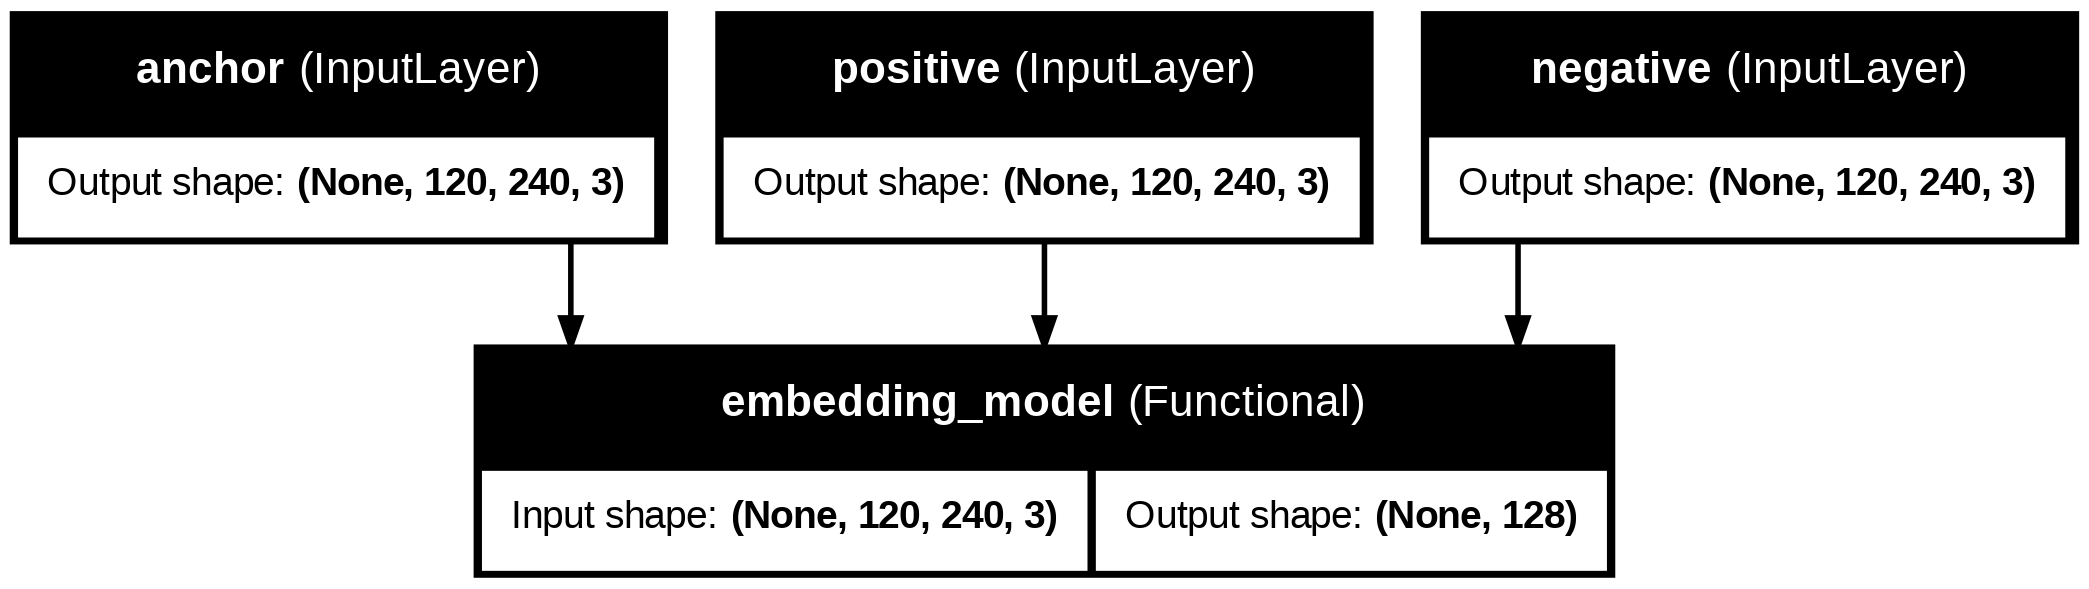

In [28]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [29]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 128)       │  2,620,352 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,620,352 (10.00 MB)

 Trainable params: 2,223,040 (8.48 MB)

 Non-trainable params: 397,312 (1.52 MB)

In [30]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_dense_1 (Dense)      │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 128)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,352 (10.00 MB)

 Trainable params: 2,223,040 (8.48 MB)

 Non-trainable params: 397,312 (1.52 MB)

In [31]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [33]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [34]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
610/610 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - an_sim: -0.0038 - ap_sim: 0.0220 - loss: 0.3749 - margin: 0.0258 - triplet_acc: 0.5628
Epoch 1: val_loss improved from None to 0.35445, saving model to checkpoints/mobile_siamese_triplet/best.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)



Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
610/610 ━━━━━━━━━━━━━━━━━━━━ 146s 147ms/step - an_sim: -0.0067 - ap_sim: 0.0288 - loss: 0.3654 - margin: 0.0355 - triplet_acc: 0.5787 - val_an_sim: 0.1052 - val_ap_sim: 0.1535 - val_loss: 0.3545 - val_margin: 0.0484 - val_triplet_acc: 0.6113 - learning_rate: 1.0000e-05
Epoch 2/30
608/610 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - an_sim: -0.0075 - ap_sim: 0.0625 - loss: 0.3347 - margin: 0.0700 - triplet_acc: 0.6422
Epoch 2: val_loss improved from 0.35445 to 0.31400, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
610/610 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - an_sim: -0.0080 - ap_sim: 0.0790 - loss: 0.3221 - margin: 0.0870 - triplet_acc: 0.6531 - val_an_sim: 0.0620 - val_ap_sim: 0.1585 - val_loss: 0.3140 - val_margin: 0.0965 - val_triplet_acc: 0.6587 - learning_rate: 1.0000e-05
Epoch 3/30
607/610 ━━━━━━━━━━━━━━━━━━━━ 0s 3

In [35]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

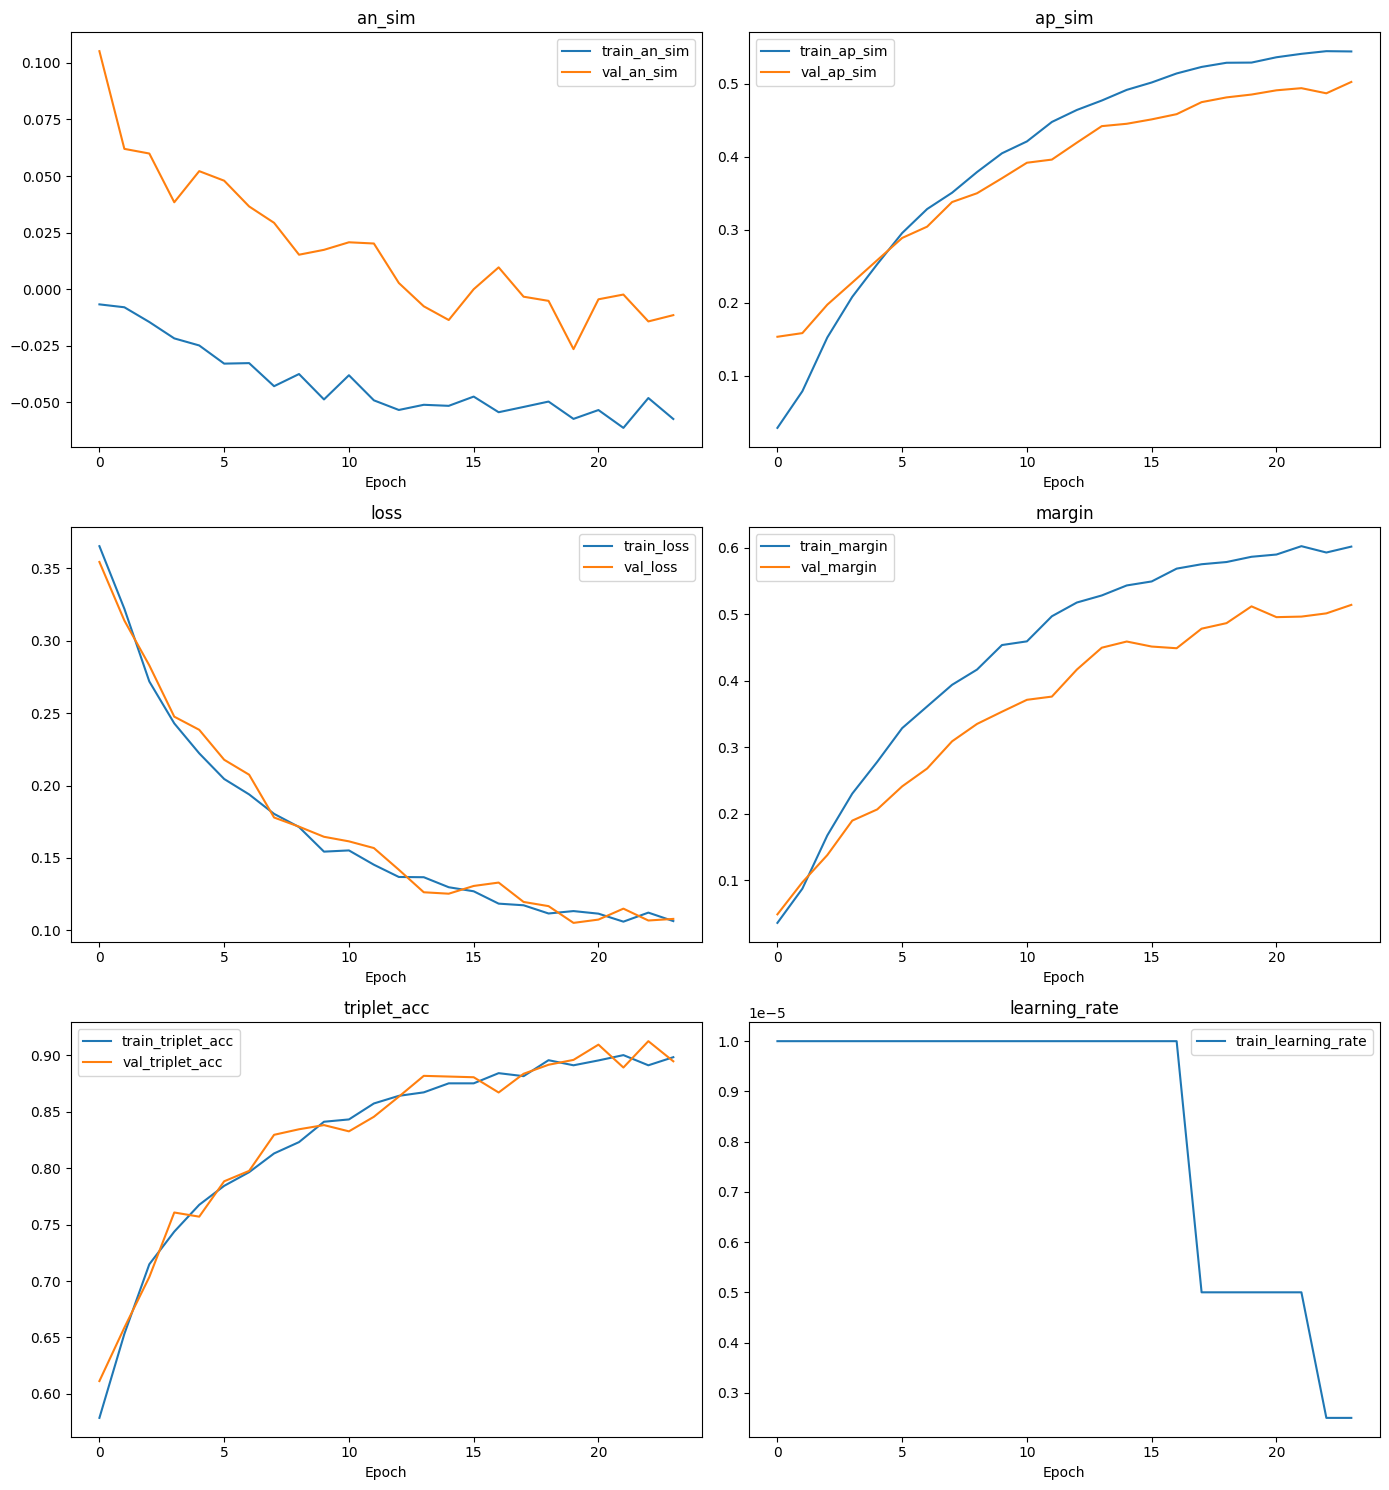

In [36]:
plot_keras_history(history)

In [37]:
os.makedirs("./models", exist_ok=True)
trainer.siamese_network.save(f"./models/mobilenet_siamese_model_10_{config.current_time}.keras")
trainer.embedding_model.save(f"./models/mobilenet_embedding_model_10_{config.current_time}.keras")

In [ ]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_10_20260320-070014.keras")

In [38]:
metrics_val = trainer.evaluate_dict(val_triplet)
metrics_val

407/407 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - an_sim: -0.0071 - ap_sim: 0.4877 - loss: 0.1075 - margin: 0.4948 - triplet_acc: 0.8991


{'an_sim': -0.0070588551461696625,
 'ap_sim': 0.48769593238830566,
 'loss': 0.1074942946434021,
 'margin': 0.49475476145744324,
 'triplet_acc': 0.8991389870643616}

In [39]:
metrics_test = trainer.evaluate_dict(test_triplet)
metrics_test

109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - an_sim: -0.0409 - ap_sim: 0.5390 - loss: 0.0877 - margin: 0.5800 - triplet_acc: 0.9195


{'an_sim': -0.0409202016890049,
 'ap_sim': 0.5390348434448242,
 'loss': 0.087706558406353,
 'margin': 0.579954981803894,
 'triplet_acc': 0.9195402264595032}

In [40]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [41]:
def display_heatmap(df: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title("Confusion Matrix")
    plt.show()

In [42]:
triplet_evaluator = TripletEvaluator(
    model=trainer,
    logger=logger,
)

In [43]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

11:35:02 - mobile_test_10_4 - INFO - === Triplet Evaluation Started ===
11:35:02 - mobile_test_10_4 - INFO - === Collecting triplet results ===
11:35:12 - mobile_test_10_4 - INFO - Total triplets collected: 109
11:35:12 - mobile_test_10_4 - INFO - [LOCAL] acc=0.9172 gap=0.5846 error=0.0828 auc=0.9231
11:35:12 - mobile_test_10_4 - INFO - === Computing global metrics ===
11:35:12 - mobile_test_10_4 - INFO - === Global metrics computed ===
11:35:12 - mobile_test_10_4 - INFO - === Triplet Evaluation Finished ===


In [44]:
triplet_report.local_metrics.auc, triplet_report.local_metrics.triplet_accuracy

(0.9231074118113357, 0.9172413793103448)

In [45]:
triplet_report.df_triplets

,anchor_idx,anchor_label,pred_idx,pred_label,positive_label,negative_label,sim_ap,sim_an,gap,correct
0,10,0,31,0,0,4,0.613499,0.117213,0.496287,True
1,113,2,99,2,2,8,0.639131,0.482292,0.156839,True
2,411,9,396,9,9,4,0.579519,-0.319768,0.899287,True
3,94,2,117,2,2,3,0.829451,0.274648,0.554803,True
4,238,5,234,5,5,6,0.342235,0.019791,0.322444,True
...,...,...,...,...,...,...,...,...,...,...
430,159,3,152,3,3,6,0.472473,-0.333195,0.805668,True
431,419,9,396,9,9,5,0.529614,-0.036642,0.566256,True
432,5,0,22,0,0,5,0.539172,0.395375,0.143798,True
433,99,2,92,2,2,9,0.763544,-0.465110,1.228654,True


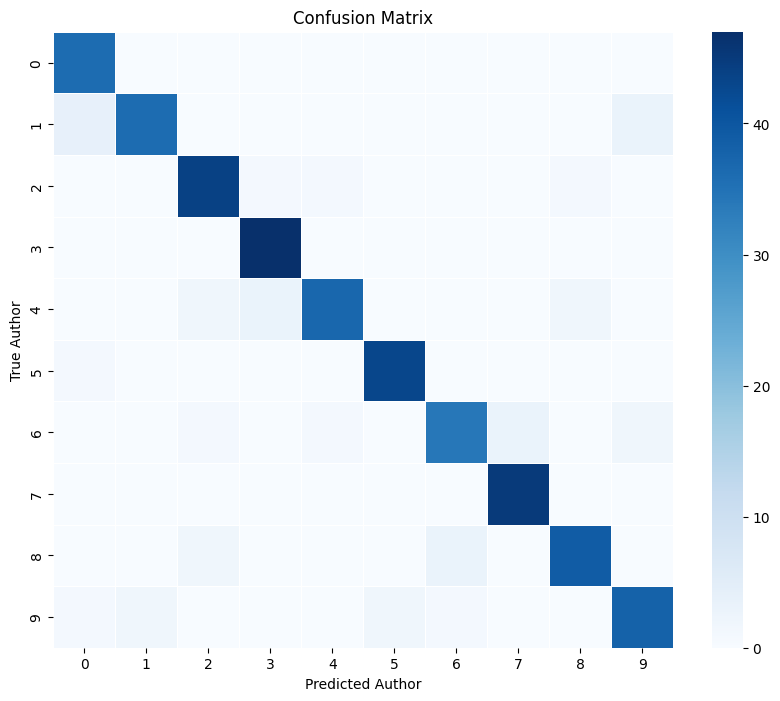

In [46]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [47]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.810250,36,1.000000,1.000000
1,1,1,1.0,0.661708,36,0.900578,0.900578
2,2,2,1.0,0.709991,44,0.932894,0.932894
3,3,3,1.0,0.649114,47,0.892148,0.892148
4,4,4,1.0,0.530383,37,0.812679,0.812679
5,5,5,1.0,0.759380,43,0.965952,0.965952
6,6,6,1.0,0.598490,34,0.858265,0.858265
7,7,7,1.0,0.628093,45,0.878078,0.878078
8,8,8,1.0,0.642788,39,0.887914,0.887914
9,9,9,1.0,0.536568,38,0.816819,0.816819


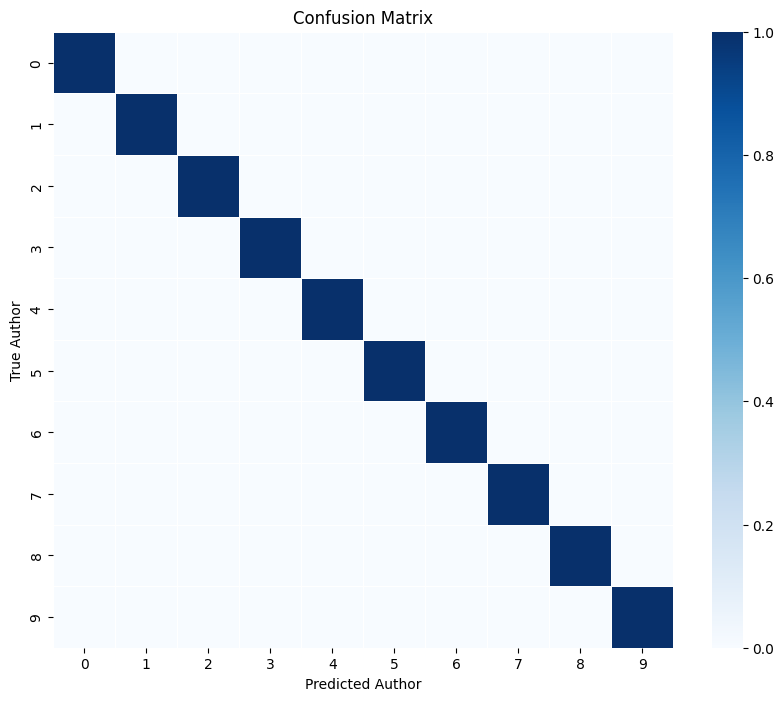

In [48]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [49]:
train_gen = DataGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [50]:
display_generator_info(train_gen)

11:36:29 - mobile_test_10_4 - INFO - Generator: DataGenerator
11:36:29 - mobile_test_10_4 - INFO - Number of samples: 4875
11:36:29 - mobile_test_10_4 - INFO - Batch size: 8
11:36:29 - mobile_test_10_4 - INFO - Steps per epoch: 610
11:36:29 - mobile_test_10_4 - INFO - Shape: (180, 360)
11:36:29 - mobile_test_10_4 - INFO - Number of authors: 10


In [51]:
display_generator_info(val_gen)

11:36:30 - mobile_test_10_4 - INFO - Generator: DataGenerator
11:36:30 - mobile_test_10_4 - INFO - Number of samples: 1626
11:36:30 - mobile_test_10_4 - INFO - Batch size: 4
11:36:30 - mobile_test_10_4 - INFO - Steps per epoch: 407
11:36:30 - mobile_test_10_4 - INFO - Shape: (180, 360)
11:36:30 - mobile_test_10_4 - INFO - Number of authors: 10


In [52]:
display_generator_info(test_gen)

11:36:31 - mobile_test_10_4 - INFO - Generator: DataGenerator
11:36:31 - mobile_test_10_4 - INFO - Number of samples: 435
11:36:31 - mobile_test_10_4 - INFO - Batch size: 4
11:36:31 - mobile_test_10_4 - INFO - Steps per epoch: 109
11:36:31 - mobile_test_10_4 - INFO - Shape: (180, 360)
11:36:31 - mobile_test_10_4 - INFO - Number of authors: 10


In [53]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [ ]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [54]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [56]:
val_gen_results = emb_evaluator.evaluate(val_gen)

11:37:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Starting evaluation
11:37:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Preparing embeddings for distance computation
11:37:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(1626, 128)
11:37:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Building author pair similarities
11:37:09 - mobile_test_10_4 - INFO - [Pairs] Built in 0.04s
11:37:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


11:37:21 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] UMAP completed in 11.99s
11:37:21 - mobile_test_10_4 - INFO - [UMAP] Completed in 12.00s
11:37:21 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
11:37:21 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] intra=0.5152 | inter=0.9955 | ratio=0.5176 | time=0.00s
11:37:21 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
11:37:21 - mobile_test_10_4 - INFO - [Pipeline] Applying strategy: 1nn
11:37:21 - mobile_test_10_4 - INFO - [Strategy:1NN] Computing similarity matrix
11:37:21 - mobile_test_10_4 - INFO - [Strategy:1NN] Accuracy=0.7325
11:37:21 - mobile_test_10_4 - INFO - [Strategy: 1nn] patch_acc=0.7325 | vote_acc=1.0000 | score_acc=0.6000 | time=0.04s
11:37:21 - mobile_test_10_4 - INFO - [Pipeline] Applying strategy: mean
11:37:21 - mobile_test_10_4 - INFO - [Strategy:Mean] Computing author mean similarity
11:37:21 - mobile_test_10_4 - INFO 

In [57]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

11:37:55 - mobile_test_10_4 - INFO - Intra distance: 0.5152241587638855
11:37:55 - mobile_test_10_4 - INFO - Inter distance: 0.9954897165298462
11:37:55 - mobile_test_10_4 - INFO - Strategy: 1nn
11:37:55 - mobile_test_10_4 - INFO - Patch accuracy: 0.7325
11:37:55 - mobile_test_10_4 - INFO - Vote accuracy:  1.0000
11:37:55 - mobile_test_10_4 - INFO - Score accuracy: 0.6000
11:37:55 - mobile_test_10_4 - INFO - ----------------------------------------
11:37:55 - mobile_test_10_4 - INFO - Strategy: mean
11:37:55 - mobile_test_10_4 - INFO - Patch accuracy: 0.6820
11:37:55 - mobile_test_10_4 - INFO - Vote accuracy:  0.7000
11:37:55 - mobile_test_10_4 - INFO - Score accuracy: 0.4000
11:37:55 - mobile_test_10_4 - INFO - ----------------------------------------
11:37:55 - mobile_test_10_4 - INFO - Strategy: centroid
11:37:55 - mobile_test_10_4 - INFO - Patch accuracy: 0.7601
11:37:55 - mobile_test_10_4 - INFO - Vote accuracy:  1.0000
11:37:55 - mobile_test_10_4 - INFO - Score accuracy: 0.5000
1

In [59]:
test_gen_results = emb_evaluator.evaluate(test_gen)

11:38:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Starting evaluation
11:38:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Preparing embeddings for distance computation
11:38:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(435, 128)
11:38:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Building author pair similarities
11:38:09 - mobile_test_10_4 - INFO - [Pairs] Built in 0.02s
11:38:09 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


11:38:10 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] UMAP completed in 0.88s
11:38:10 - mobile_test_10_4 - INFO - [UMAP] Completed in 0.88s
11:38:10 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
11:38:10 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] intra=0.4459 | inter=1.0401 | ratio=0.4286 | time=0.00s
11:38:10 - mobile_test_10_4 - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
11:38:10 - mobile_test_10_4 - INFO - [Pipeline] Applying strategy: 1nn
11:38:10 - mobile_test_10_4 - INFO - [Strategy:1NN] Computing similarity matrix
11:38:10 - mobile_test_10_4 - INFO - [Strategy:1NN] Accuracy=0.8989
11:38:10 - mobile_test_10_4 - INFO - [Strategy: 1nn] patch_acc=0.8989 | vote_acc=1.0000 | score_acc=0.7000 | time=0.02s
11:38:10 - mobile_test_10_4 - INFO - [Pipeline] Applying strategy: mean
11:38:10 - mobile_test_10_4 - INFO - [Strategy:Mean] Computing author mean similarity
11:38:10 - mobile_test_10_4 - INFO - 

In [60]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

11:38:36 - mobile_test_10_4 - INFO - Intra distance: 0.44585660099983215
11:38:36 - mobile_test_10_4 - INFO - Inter distance: 1.040144920349121
11:38:36 - mobile_test_10_4 - INFO - Strategy: 1nn
11:38:36 - mobile_test_10_4 - INFO - Patch accuracy: 0.8989
11:38:36 - mobile_test_10_4 - INFO - Vote accuracy:  1.0000
11:38:36 - mobile_test_10_4 - INFO - Score accuracy: 0.7000
11:38:36 - mobile_test_10_4 - INFO - ----------------------------------------
11:38:36 - mobile_test_10_4 - INFO - Strategy: mean
11:38:36 - mobile_test_10_4 - INFO - Patch accuracy: 0.7402
11:38:36 - mobile_test_10_4 - INFO - Vote accuracy:  0.8000
11:38:36 - mobile_test_10_4 - INFO - Score accuracy: 0.3000
11:38:36 - mobile_test_10_4 - INFO - ----------------------------------------
11:38:36 - mobile_test_10_4 - INFO - Strategy: centroid
11:38:36 - mobile_test_10_4 - INFO - Patch accuracy: 0.8437
11:38:36 - mobile_test_10_4 - INFO - Vote accuracy:  1.0000
11:38:36 - mobile_test_10_4 - INFO - Score accuracy: 0.5000
1

In [61]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    loader=test.loader,
)

In [ ]:
viz.set_strategy("1nn")

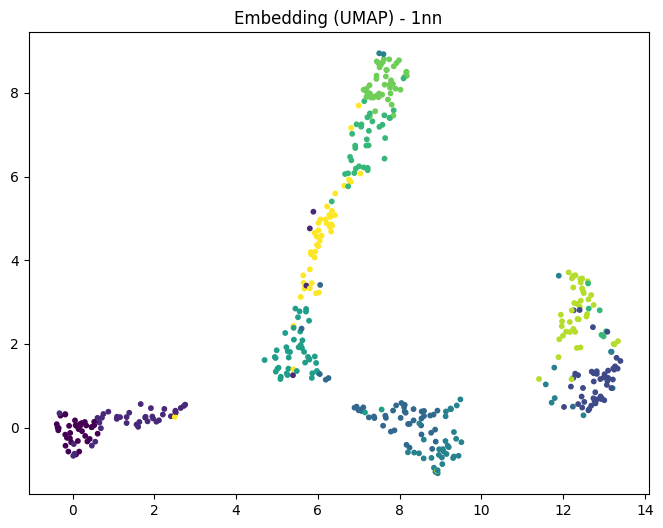

In [62]:
viz.plot_embeddings_2d()

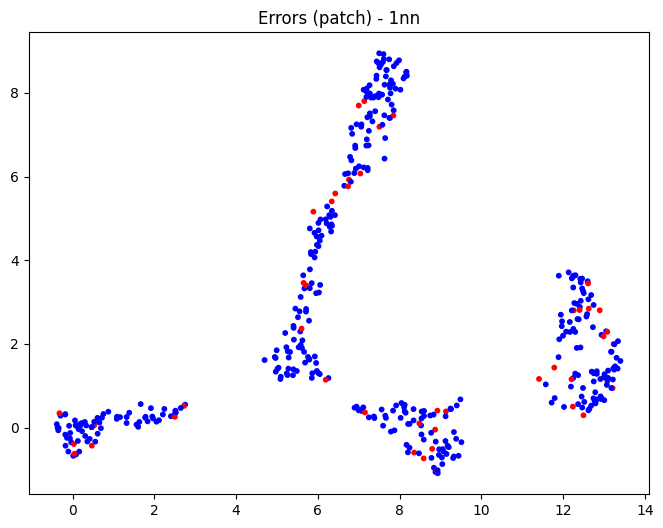

In [63]:
viz.plot_errors_2d(level="patch")

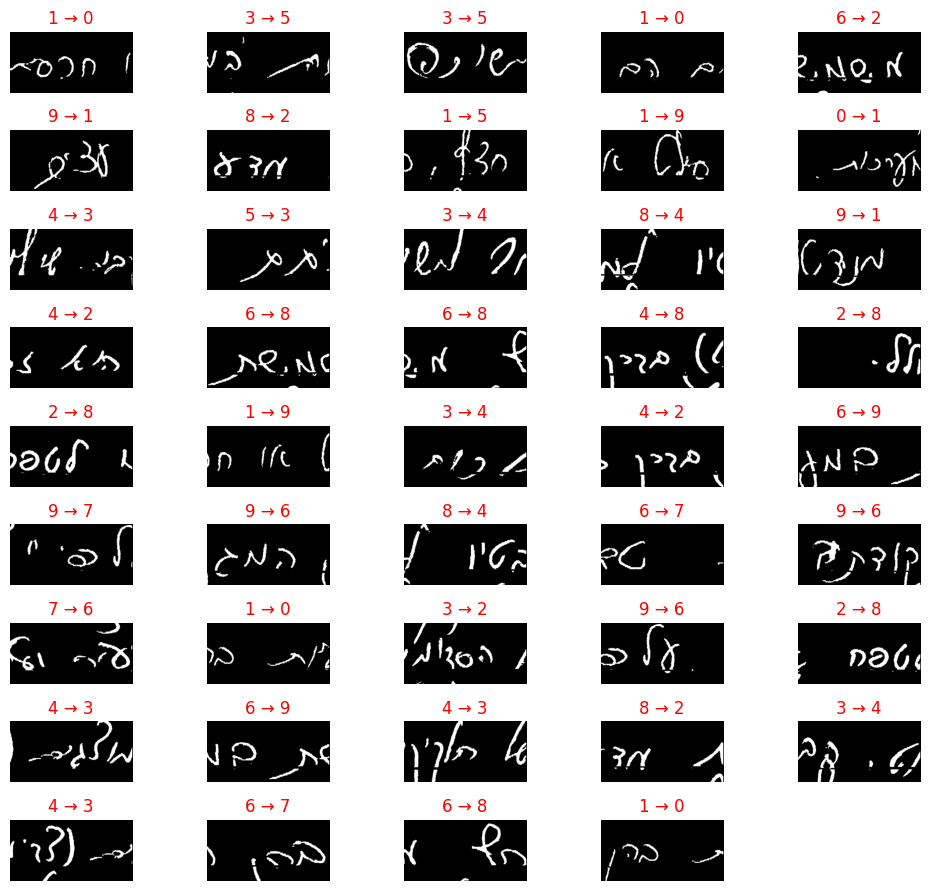

In [64]:
viz.plot_error_images()

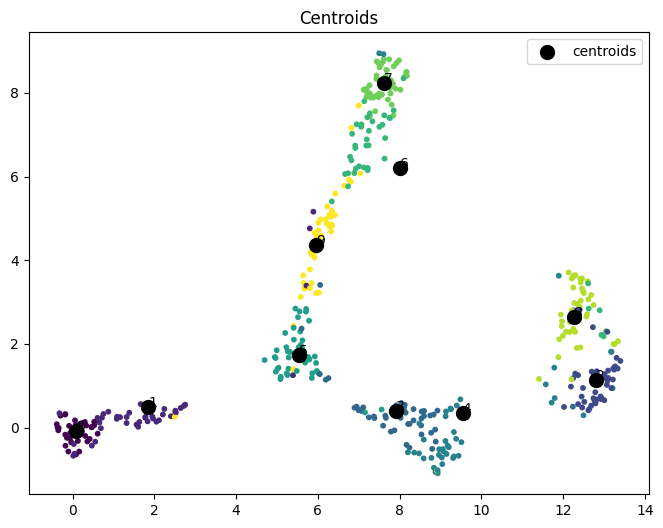

In [65]:
viz.plot_centroids()

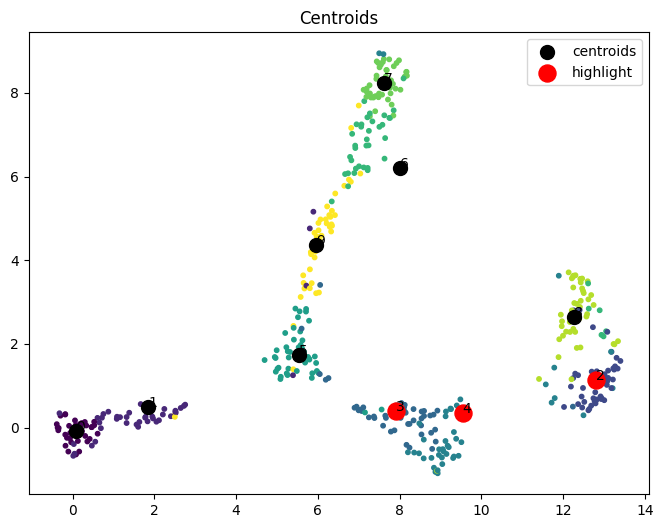

In [66]:
viz.plot_centroids([2, 3, 4])

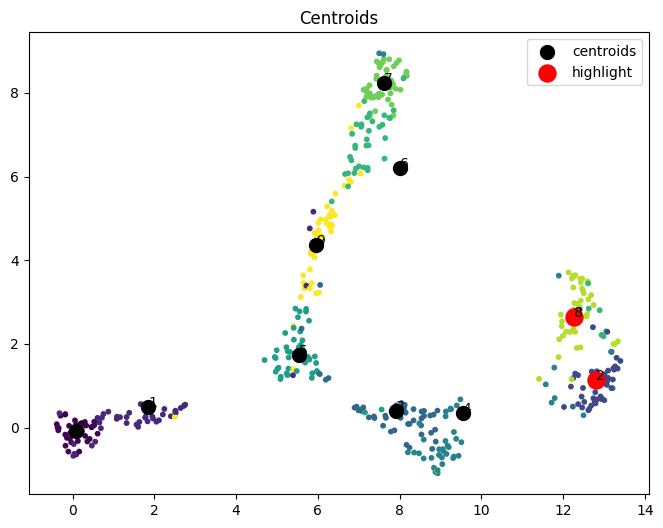

In [77]:
viz.plot_centroids([2, 8])

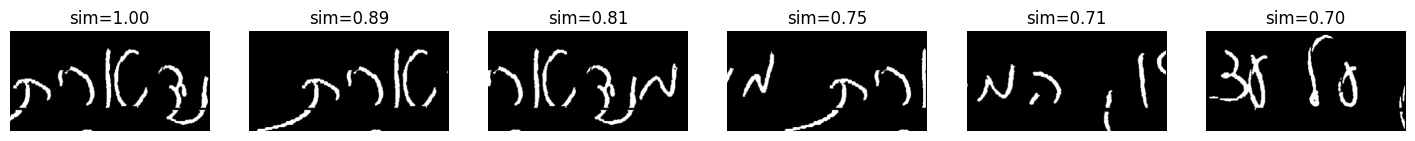

In [76]:
viz.show_nearest(df_idx=2, k=6)

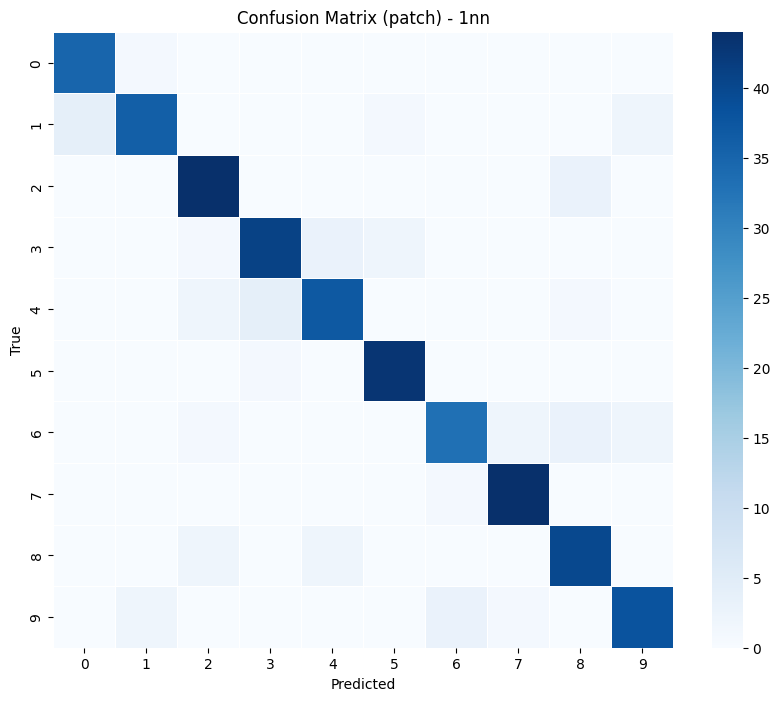

In [67]:
viz.plot_confusion(level="patch")

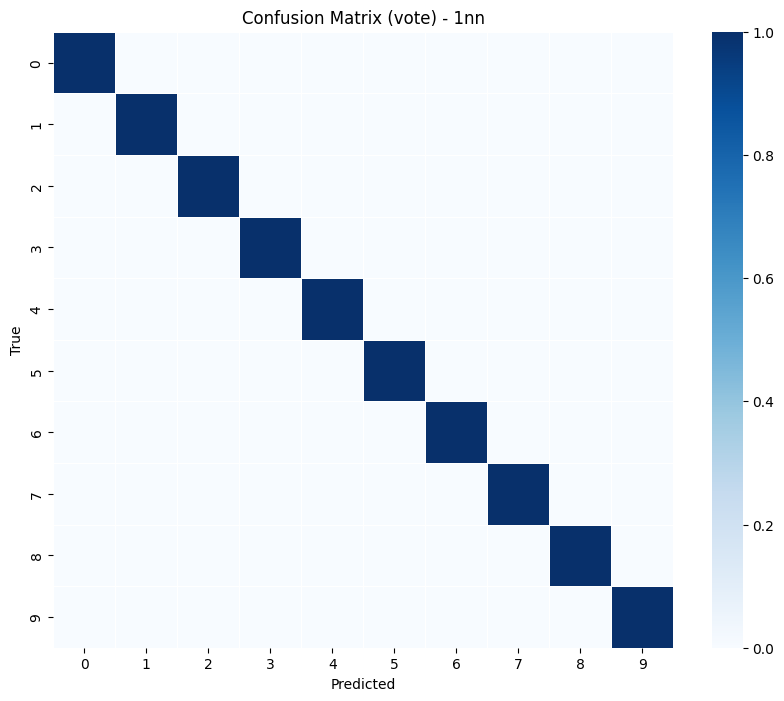

In [68]:
viz.plot_confusion(level="vote")